Importing the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score , precision_score , recall_score , precision_recall_curve , confusion_matrix , auc , classification_report 
import xgboost as xgb
import optuna

d:\Fraud-Detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading the data

In [2]:
X_train_scaled = pd.read_parquet('../data/processed/X_train_scaled.parquet')
X_val_scaled   = pd.read_parquet('../data/processed/X_val_scaled.parquet')
X_test_scaled  = pd.read_parquet('../data/processed/X_test_scaled.parquet')

X_train = pd.read_parquet('../data/processed/X_train.parquet')
X_val   = pd.read_parquet('../data/processed/X_val.parquet')
X_test  = pd.read_parquet('../data/processed/X_test.parquet')

y_train = pd.read_parquet('../data/processed/y_train.parquet')['isFraud']
y_val   = pd.read_parquet('../data/processed/y_val.parquet')['isFraud']
y_test  = pd.read_parquet('../data/processed/y_test.parquet')['isFraud']

Creating an Evaluator Helper Function

In [3]:
# Performing full evaluation of the model , returning metrics deictionary and printing a clean summary

def evaluate_model(model , X , y , model_name , threshold= 0.5):
    proba = model.predict_proba(X)[ : , 1]   #returns 2D array with probabilty of fraud/not fraud ,[ : , 1] we only take fraud probabilty
    preds = (proba >= threshold).astype(int)        #converts probabilities to 0/1 predictions at your chosen threshold:

    # Metrics
    precision = precision_score(y , preds , zero_division=0)
    recall    = recall_score(y, preds, zero_division=0)
    f1        = f1_score(y, preds, zero_division=0)

    pr_precision , pr_recall , _ = precision_recall_curve(y , proba)
    pr_auc = auc(pr_recall, pr_precision) 

    cm = confusion_matrix(y, preds)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)                  # fraction of legitimate transactions we wrongly blocked

    print(f"Model: {model_name} , Threshold: {threshold}")
    print(f"Precision Recall AUC: {pr_auc:.4f}")
    print(f"F1 score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"FPR:       {fpr:.4f}")
    print(f"{fpr*100:.2f}% legitimate transactions blocked")
    print(f"\nConfusion Matrix:")
    print(f"  TP: {tp:,}  FP: {fp:,}")
    print(f"  FN: {fn:,}  TN: {tn:,}")

    return {
        'model_name': model_name,
        'threshold': threshold,
        'pr_auc': pr_auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'fpr': fpr,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    }

In [10]:
X_train_raw = pd.read_parquet('../data/processed/X_train_raw.parquet')
y_train_raw = pd.read_parquet('../data/processed/y_train_raw.parquet')['isFraud']

neg = (y_train_raw == 0).sum()
pos = (y_train_raw == 1).sum()
spw = neg / pos

print(f"Shape: {X_train_raw.shape}")
print(f"Fraud rate: {y_train_raw.mean()*100:.2f}%")
print(f"scale_pos_weight: {spw:.2f}")

Shape: (354324, 216)
Fraud rate: 3.38%
scale_pos_weight: 28.56


Re running XGBoost default but on raw datasets

In [11]:
print("Training XGBoost default on raw (non-SMOTE) data...")

xgb_default = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,   # 28.56 — handles imbalance natively
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_default.fit(
    X_train_raw, y_train_raw,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_default_metrics = evaluate_model(
    xgb_default , X_val, y_val , model_name="XGBoost Default (raw)" , threshold=0.5)

Training XGBoost default on raw (non-SMOTE) data...
Model: XGBoost Default (raw) , Threshold: 0.5
Precision Recall AUC: 0.5664
F1 score: 0.4271
Precision: 0.3113
Recall:    0.6803
FPR:       0.0633
6.33% legitimate transactions blocked

Confusion Matrix:
  TP: 2,432  FP: 5,381
  FN: 1,143  TN: 79,625


Running Optuna Hyperparameter tuning now 

In [12]:
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': spw,
        'eval_metric':      'aucpr',
        'random_state':     42,
        'n_jobs':           -1,
        'verbosity':        0
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train_raw, y_train_raw,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    proba = model.predict_proba(X_val)[:, 1]
    pr_prec, pr_rec, _ = precision_recall_curve(y_val, proba)
    return auc(pr_rec, pr_prec)

study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Seed with default params as first trial
study_xgb.enqueue_trial({
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0
})

print("Running Optuna for XGBoost (50 trials)...")
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest XGBoost PR-AUC: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

[I 2026-06-10 10:19:47,026] A new study created in memory with name: no-name-d8fbaf78-08cb-4dc2-b244-68b32e953cb5


Running Optuna for XGBoost (50 trials)...


Best trial: 0. Best value: 0.566373:   2%|▏         | 1/50 [00:13<11:05, 13.57s/it]

[I 2026-06-10 10:20:00,620] Trial 0 finished with value: 0.566373022020713 and parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0}. Best is trial 0 with value: 0.566373022020713.


Best trial: 0. Best value: 0.566373:   4%|▍         | 2/50 [00:30<12:12, 15.27s/it]

...

[I 2026-06-10 10:33:28,456] Trial 47 finished with value: 0.566613413367414 and parameters: {'n_estimators': 204, 'max_depth': 9, 'learning_rate': 0.12672470088110932, 'subsample': 0.7074446243383796, 'colsample_bytree': 0.8690886207954589, 'min_child_weight': 7, 'gamma': 0.8208662906415345}. Best is trial 26 with value: 0.5841082948442594.


Best trial: 26. Best value: 0.584108:  98%|█████████▊| 49/50 [13:48<00:13, 13.40s/it]

[I 2026-06-10 10:33:35,480] Trial 48 finished with value: 0.5633224084427023 and parameters: {'n_estimators': 101, 'max_depth': 10, 'learning_rate': 0.15658186208866673, 'subsample': 0.9257824469438295, 'colsample_bytree': 0.7485861219973629, 'min_child_weight': 9, 'gamma': 1.6791644663778826}. Best is trial 26 with value: 0.5841082948442594.


Best trial: 26. Best value: 0.584108: 100%|██████████| 50/50 [13:56<00:00, 16.74s/it]

[I 2026-06-10 10:33:43,951] Trial 49 finished with value: 0.5334525902134593 and parameters: {'n_estimators': 176, 'max_depth': 5, 'learning_rate': 0.03898571256948453, 'subsample': 0.8654334280301261, 'colsample_bytree': 0.9658465130246872, 'min_child_weight': 8, 'gamma': 0.2873897420738205}. Best is trial 26 with value: 0.5841082948442594.

Best XGBoost PR-AUC: 0.5841
Best params: {'n_estimators': 275, 'max_depth': 9, 'learning_rate': 0.08784423028718466, 'subsample': 0.9520978812241658, 'colsample_bytree': 0.9106621066812718, 'min_child_weight': 9, 'gamma': 1.1307446836014143}


In [20]:
best_xgb_params = study_xgb.best_params
best_xgb_params

{'n_estimators': 275,
 'max_depth': 9,
 'learning_rate': 0.08784423028718466,
 'subsample': 0.9520978812241658,
 'colsample_bytree': 0.9106621066812718,
 'min_child_weight': 9,
 'gamma': 1.1307446836014143}

In [13]:
best_xgb_params = study_xgb.best_params
best_xgb_params.update({
    'scale_pos_weight': spw,
    'eval_metric':      'aucpr',
    'random_state':     42,
    'n_jobs':           -1,
    'verbosity':        0
})

xgb_best = xgb.XGBClassifier(**best_xgb_params)
xgb_best.fit(
    X_train_raw, y_train_raw,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_best_metrics = evaluate_model(
    xgb_best, X_val, y_val,
    model_name="XGBoost Optuna",
    threshold=0.5
)

# Overfit check
train_metrics = evaluate_model(
    xgb_best, X_train_raw, y_train_raw,
    model_name="XGBoost Optuna (TRAIN)",
    threshold=0.5
)

Model: XGBoost Optuna , Threshold: 0.5
Precision Recall AUC: 0.5841
F1 score: 0.5059
Precision: 0.4311
Recall:    0.6120
FPR:       0.0340
3.40% legitimate transactions blocked

Confusion Matrix:
  TP: 2,188  FP: 2,887
  FN: 1,387  TN: 82,119
Model: XGBoost Optuna (TRAIN) , Threshold: 0.5
Precision Recall AUC: 0.9334
F1 score: 0.7019
Precision: 0.5516
Recall:    0.9647
FPR:       0.0275
2.75% legitimate transactions blocked

Confusion Matrix:
  TP: 11,565  FP: 9,401
  FN: 423  TN: 332,935


Even if AUC has lowered a little bit , precision and recall have drastically improved , so keeping these parameters only and finding the best threshold

In [16]:
proba_xgb = xgb_best.predict_proba(X_val)[:, 1]
pr_prec, pr_rec, thresholds = precision_recall_curve(y_val, proba_xgb)

f1_scores = 2 * (pr_prec * pr_rec) / (pr_prec + pr_rec + 1e-8)
best_idx  = f1_scores.argmax()
best_threshold_xgb = thresholds[best_idx]

print(f"Best threshold: {best_threshold_xgb:.4f}")

Best threshold: 0.8294


In [17]:
xgb_best_metrics_thresh = evaluate_model(xgb_best , X_val , y_val , 
                                         model_name = 'XGBoost Optuna(Best threshold)' , 
                                         threshold=best_threshold_xgb)
xgb_best_metrics_thresh

Model: XGBoost Optuna(Best threshold) , Threshold: 0.8293766975402832
Precision Recall AUC: 0.5841
F1 score: 0.5814
Precision: 0.7557
Recall:    0.4724
FPR:       0.0064
0.64% legitimate transactions blocked

Confusion Matrix:
  TP: 1,689  FP: 546
  FN: 1,886  TN: 84,460


{'model_name': 'XGBoost Optuna(Best threshold)',
 'threshold': np.float32(0.8293767),
 'pr_auc': 0.5841082948442594,
 'f1': 0.5814113597246128,
 'precision': 0.7557046979865771,
 'recall': 0.47244755244755243,
 'fpr': np.float64(0.006423076018163424),
 'tp': np.int64(1689),
 'fp': np.int64(546),
 'fn': np.int64(1886),
 'tn': np.int64(84460)}

Precision Recall Curve

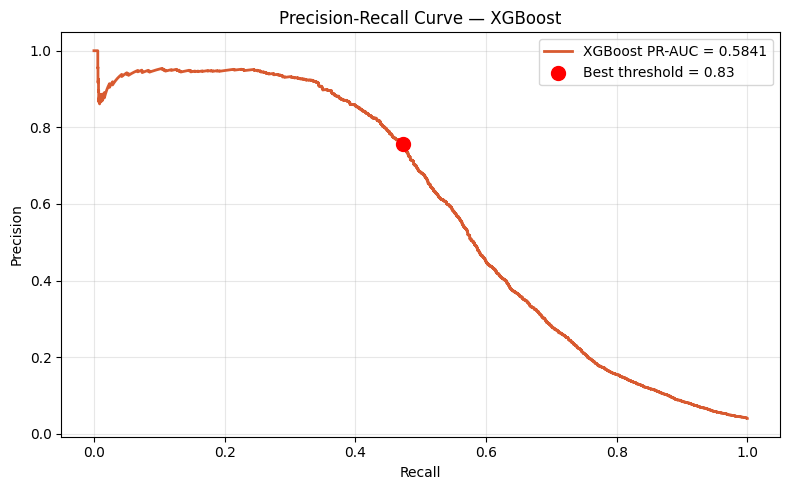

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(pr_rec, pr_prec, color='#D85A30', lw=2,
         label=f'XGBoost PR-AUC = {auc(pr_rec, pr_prec):.4f}')
plt.scatter(pr_rec[best_idx], pr_prec[best_idx],
            color='red', s=100, zorder=5,
            label=f'Best threshold = {best_threshold_xgb:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/xgb_pr_curve.png', dpi=150)
plt.show()